# 02 EDA Visualization
## EDA 시각화

### Sector Trend
AFS와 저노출 비교 부문의 장기 흐름을 먼저 비교한다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:,.4f}".format)

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "outputs" / "tables").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Project root not found")

PROJECT_ROOT = find_project_root()
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def load_table(name: str) -> pd.DataFrame:
    return pd.read_csv(TABLE_DIR / name)

def show_saved_figure(fig, name: str) -> None:
    path = FIGURE_DIR / name
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(path)))

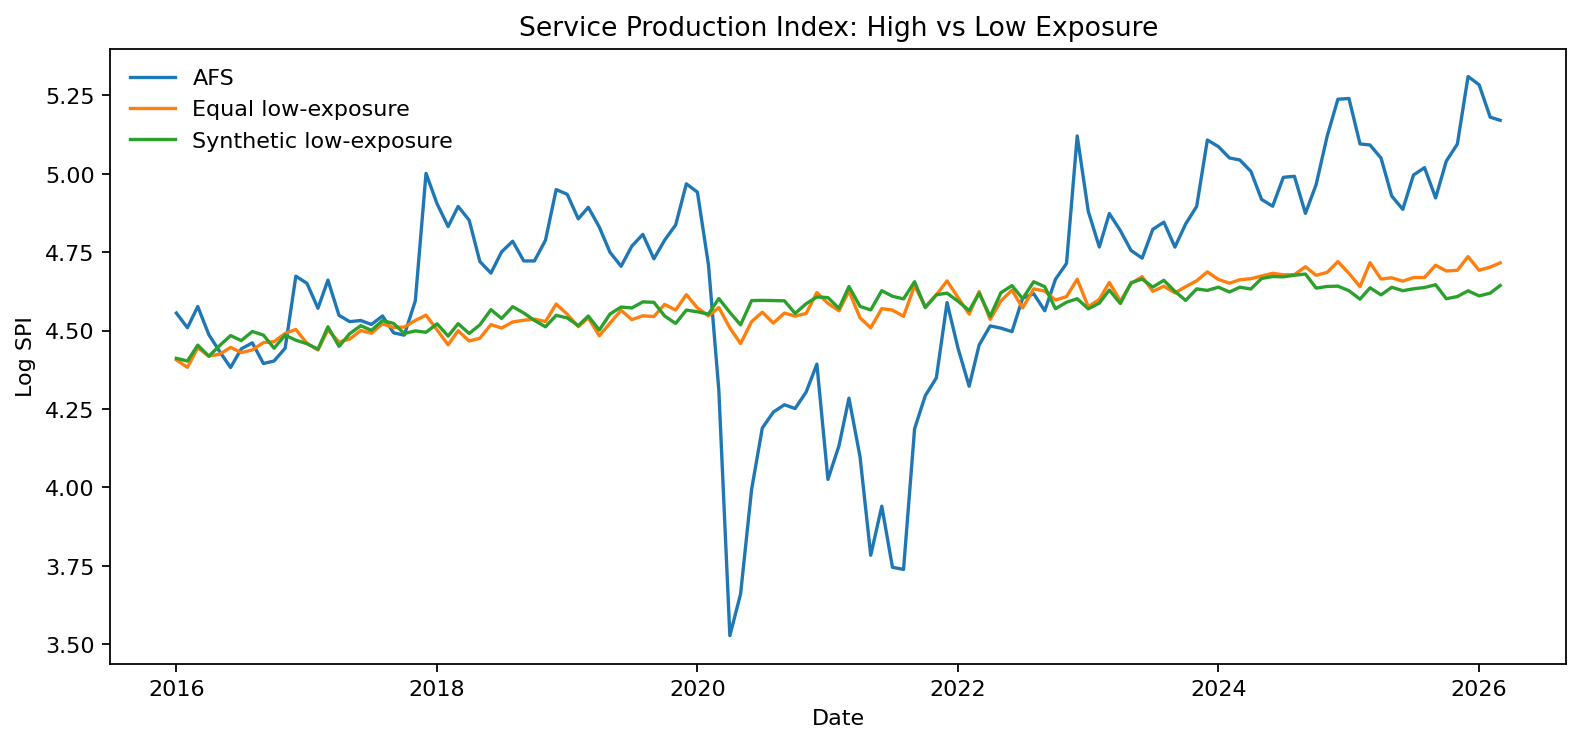

In [2]:
panel = load_table("final_monthly_model_panel.csv")
panel["date"] = pd.to_datetime(panel["date"])

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(panel["date"], panel["log_spi_afs"], label="AFS")
ax.plot(panel["date"], panel["log_low_equal_main"], label="Equal low-exposure")
ax.plot(panel["date"], panel["log_low_synthetic_main"], label="Synthetic low-exposure")
ax.set_title("Service Production Index: High vs Low Exposure")
ax.set_xlabel("Date")
ax.set_ylabel("Log SPI")
ax.legend(frameon=False)
show_saved_figure(fig, "portfolio_sector_trend.png")

AFS는 팬데믹 이후 회복 구간에서 비교 부문과 다른 움직임을 보이며, 이 차이를 정책 기간과 함께 확인한다.

### Policy Intensity
월별 정책 강도가 실제 분석 기간 어디에 놓이는지 확인한다.

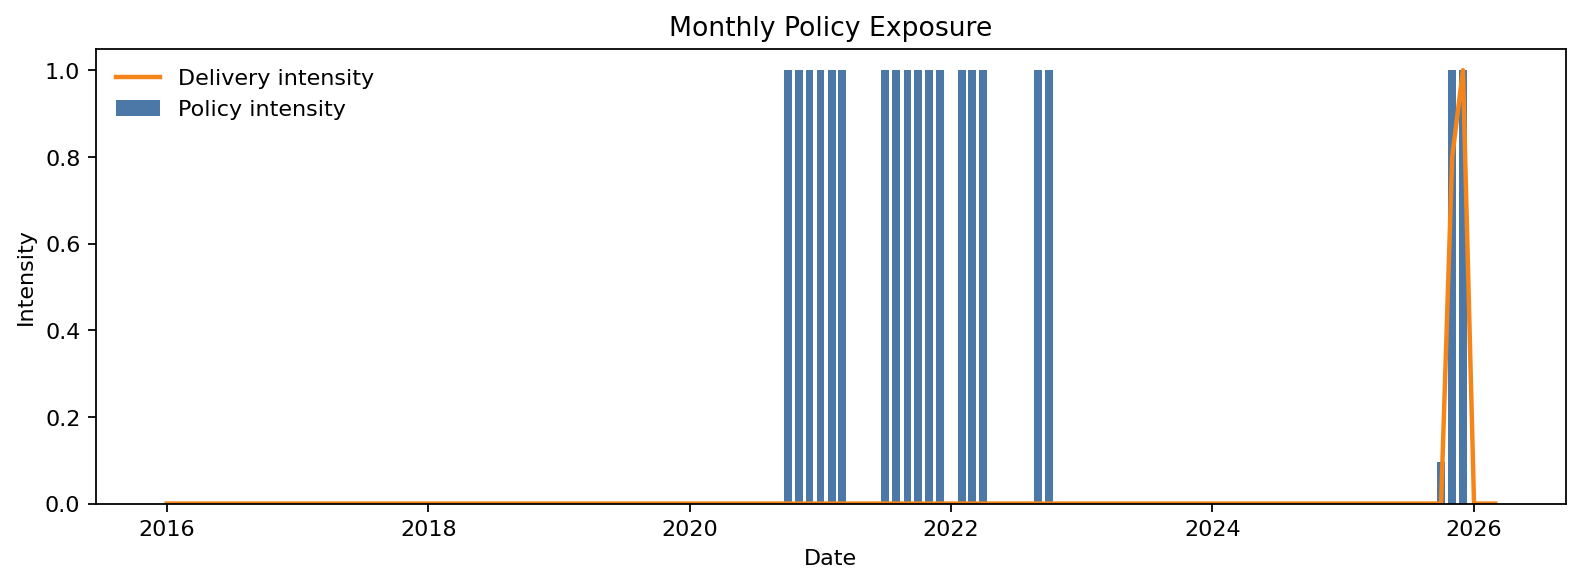

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(panel["date"], panel["policy_intensity_m"], width=22, label="Policy intensity", color="#4C78A8")
ax.plot(panel["date"], panel["delivery_intensity_m"], label="Delivery intensity", color="#F58518", linewidth=2)
ax.set_title("Monthly Policy Exposure")
ax.set_xlabel("Date")
ax.set_ylabel("Intensity")
ax.legend(frameon=False)
show_saved_figure(fig, "portfolio_policy_intensity.png")

정책은 한 번의 단일 충격이 아니라 여러 번 반복된 임시 충격으로 관찰된다.

### Relative Gap
AFS와 비교 부문의 로그 차이가 정책 구간에서 어떻게 움직이는지 본다.

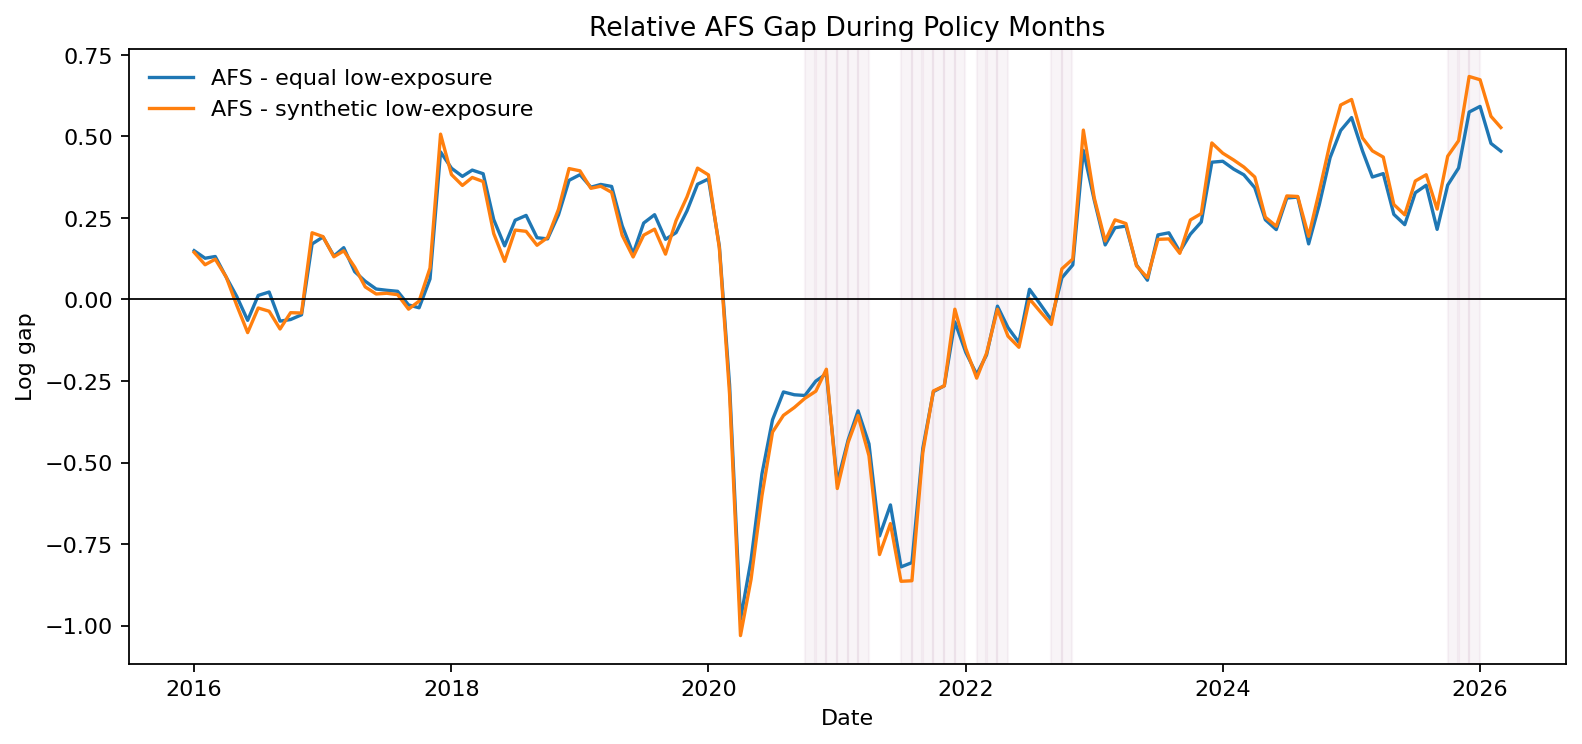

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(panel["date"], panel["gap_equal_main"], label="AFS - equal low-exposure")
ax.plot(panel["date"], panel["gap_synth_main"], label="AFS - synthetic low-exposure")

for _, row in panel.loc[panel["policy_intensity_m"] > 0].iterrows():
    ax.axvspan(row["date"], row["date"] + pd.offsets.MonthEnd(1), color="#B279A2", alpha=0.08)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Relative AFS Gap During Policy Months")
ax.set_xlabel("Date")
ax.set_ylabel("Log gap")
ax.legend(frameon=False)
show_saved_figure(fig, "portfolio_relative_gap.png")

정책 기간의 상승은 보이지만, 반복 정책과 관광 회복이 겹쳐 있어 단순 전후 비교로 상환 여력을 판단하기 어렵다.

### 2025 Clean Block
2025년 비교적 깨끗한 정책 블록을 전후 평균으로 요약한다.

In [5]:
clean_2025 = load_table("clean_2025_block_summary.csv")
clean_2025[
    [
        "outcome",
        "pre_policy_mean",
        "policy_period_mean",
        "post_policy_mean",
        "policy_minus_pre",
        "post_minus_policy",
    ]
]

,outcome,pre_policy_mean,policy_period_mean,post_policy_mean,policy_minus_pre,post_minus_policy
0,gap_equal_main,0.2945,0.4424,0.5080,0.1480,0.0656
1,gap_synth_main,0.3347,0.5361,0.5870,0.2015,0.0509
2,log_spi_afs,4.9673,5.1484,5.2115,0.1811,0.0631


2025년 블록은 정책기와 종료 후 수준을 보여주는 기술통계이며, 강한 인과 추론의 근거로 쓰지 않는다.